In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.rcParams["figure.figsize"] = (12,6)

Matplotlib is building the font cache; this may take a moment.


In [2]:
nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

print(nav.head())

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639


In [3]:
nav["date"] = pd.to_datetime(nav["date"])

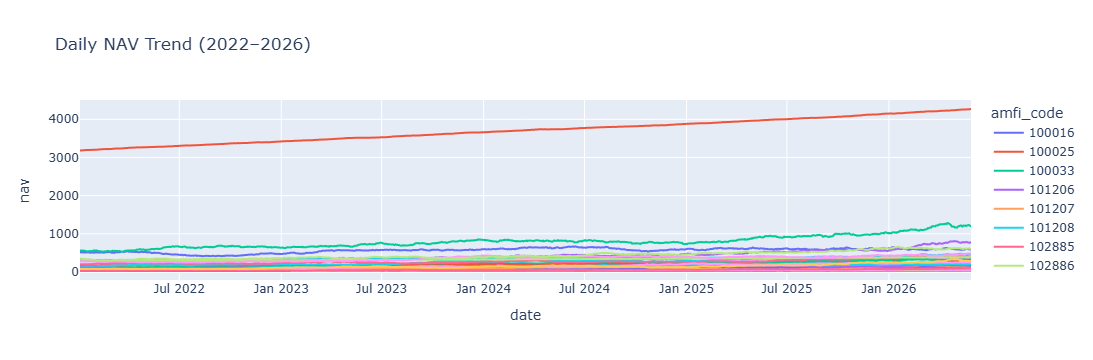

In [4]:
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022–2026)"
)

fig.show()

### Insight 1

Daily NAV values generally increased during **2023**, indicating a strong bull market. Small corrections are visible during **2024**.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

In [9]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [10]:
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


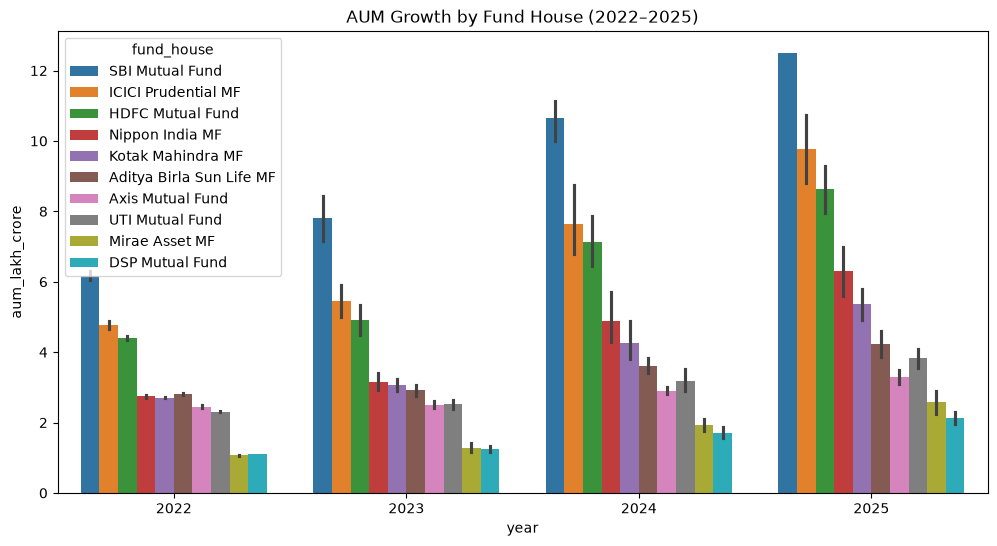

In [11]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")

plt.savefig("../reports/AUM_Growth.png", dpi=300)

plt.show()

### Insight 2

SBI Mutual Fund consistently maintained one of the highest Assets Under Management (AUM) across 2022–2025. Overall AUM increased steadily, indicating growth in the mutual fund industry.

In [12]:
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

In [13]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [14]:
sip["month"] = pd.to_datetime(sip["month"])
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


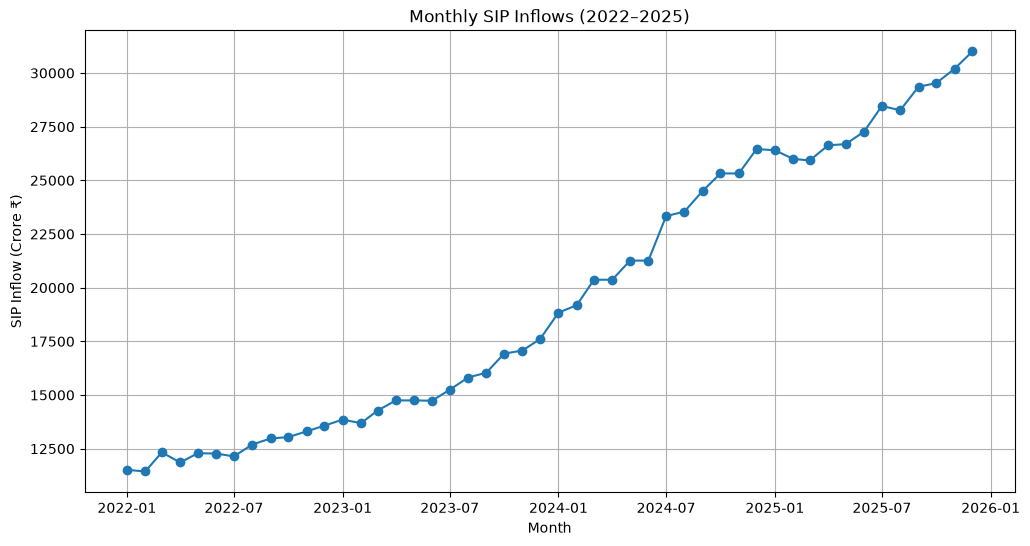

In [15]:
plt.figure(figsize=(12,6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o"
)

plt.title("Monthly SIP Inflows (2022–2025)")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore ₹)")

plt.grid(True)

plt.show()

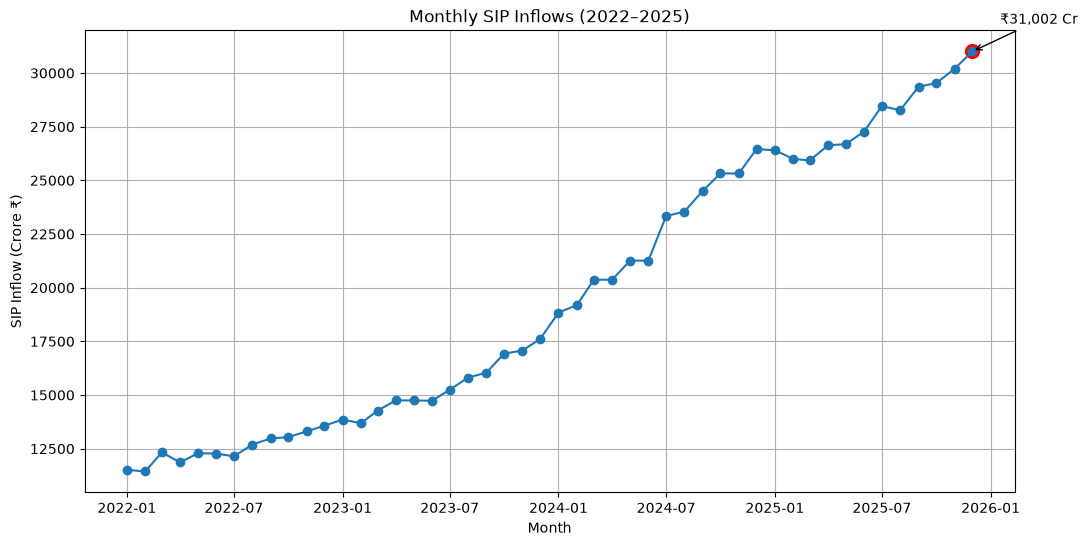

In [16]:
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

plt.figure(figsize=(12,6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o"
)

plt.scatter(
    max_row["month"],
    max_row["sip_inflow_crore"],
    color="red",
    s=100
)

plt.annotate(
    f'₹{max_row["sip_inflow_crore"]:,} Cr',
    (max_row["month"], max_row["sip_inflow_crore"]),
    xytext=(20,20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.title("Monthly SIP Inflows (2022–2025)")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore ₹)")

plt.grid(True)

plt.savefig("../reports/SIP_Inflow_Trend.png", dpi=300)

plt.show()

### Insight 3

Monthly SIP inflows showed a consistent upward trend from 2022 to 2025. The highest inflow was recorded in December 2025 at approximately ₹31,002 crore, indicating strong investor participation through SIPs.

In [17]:
category = pd.read_csv("../data/raw/05_category_inflows.csv")

category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [18]:
category["month"] = pd.to_datetime(category["month"])

category["month"] = category["month"].dt.strftime("%b-%Y")

category.head()

,month,category,net_inflow_crore
0,Apr-2024,Large Cap,2413.0
1,Apr-2024,Mid Cap,3897.0
2,Apr-2024,Small Cap,3533.0
3,Apr-2024,Flexi Cap,4947.0
4,Apr-2024,Large & Mid Cap,4214.0


In [19]:
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

heatmap_data

month,Apr-2024,Aug-2024,Dec-2024,Feb-2025,Jan-2025,Jul-2024,Jun-2024,Mar-2025,May-2024,Nov-2024,Oct-2024,Sep-2024
category,,,,,,,,,,,,
ELSS,466.0,499.0,521.0,437.0,516.0,471.0,472.0,500.0,553.0,571.0,537.0,537.0
Flexi Cap,4947.0,5562.0,4654.0,6068.0,5603.0,4869.0,4478.0,4767.0,5529.0,6111.0,6004.0,5397.0
Gilt,784.0,952.0,831.0,942.0,744.0,959.0,864.0,956.0,836.0,704.0,898.0,925.0
Hybrid,2955.0,3684.0,3538.0,3360.0,2967.0,3291.0,3163.0,2830.0,3487.0,3264.0,3314.0,3015.0
Large & Mid Cap,4214.0,5411.0,4878.0,5524.0,4816.0,5023.0,4610.0,4243.0,4368.0,5556.0,4581.0,4528.0
Large Cap,2413.0,1940.0,1923.0,1925.0,2025.0,2574.0,2519.0,2234.0,2076.0,1870.0,2255.0,1879.0
Liquid,37537.0,41952.0,34933.0,32374.0,33892.0,34643.0,40486.0,38681.0,41872.0,40506.0,39091.0,35308.0
Mid Cap,3897.0,3899.0,5023.0,4819.0,4316.0,4548.0,5047.0,5061.0,5300.0,4336.0,4106.0,4960.0
Sectoral/Thematic,8052.0,8360.0,9820.0,9215.0,7893.0,9896.0,10030.0,8614.0,8354.0,7397.0,7680.0,8518.0


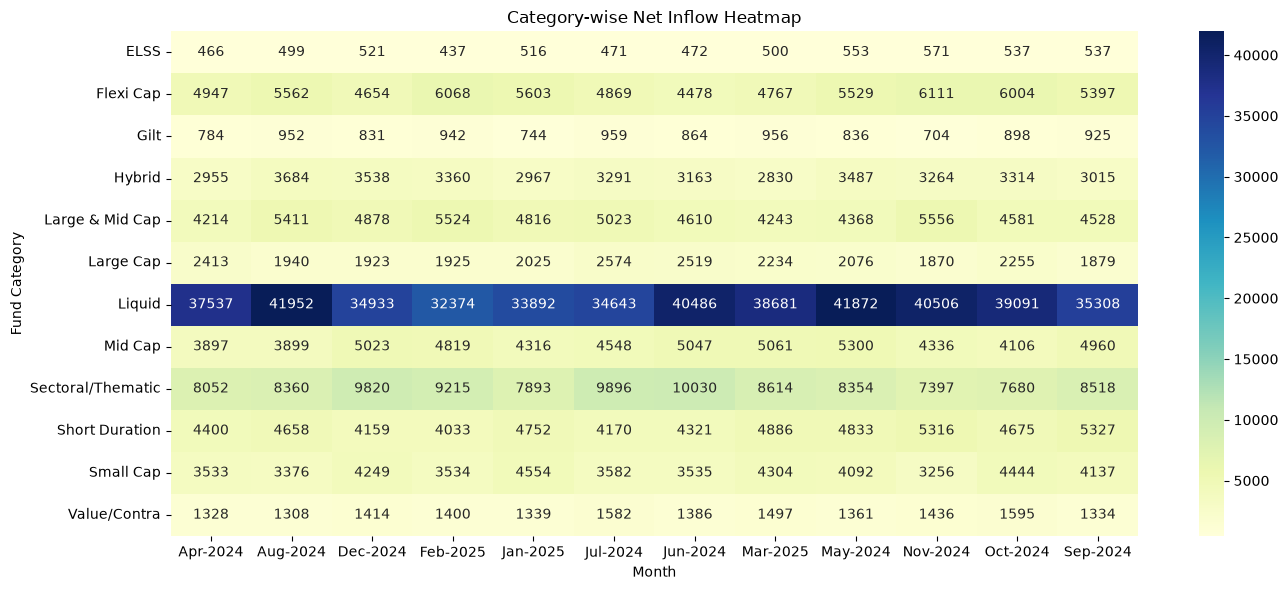

In [20]:
plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f"
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.savefig("../reports/Category_Heatmap.png", dpi=300)

plt.show()

### Insight 4

Category-wise net inflows varied across months. Flexi Cap, Mid Cap, and Small Cap funds generally attracted stronger inflows, indicating higher investor interest in equity-oriented categories.

In [21]:
age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.savefig("../reports/Age_Group_Pie.png", dpi=300)

plt.show()

NameError: name 'transactions' is not defined

In [22]:
transactions = pd.read_csv("../data/processed/investor_transactions_cleaned.csv")

In [23]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


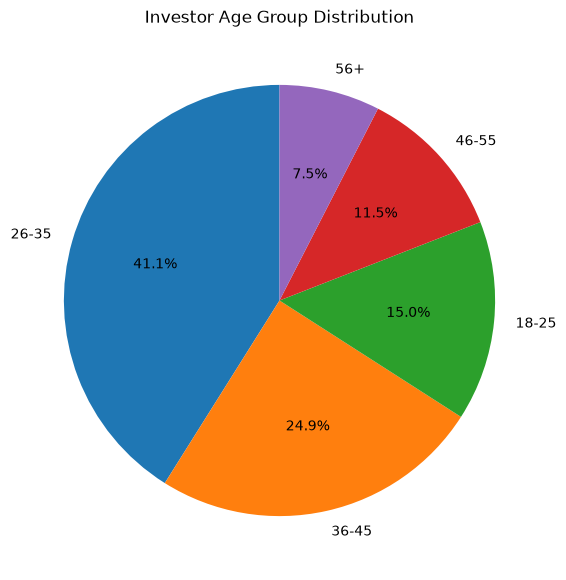

In [24]:
age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.savefig("../reports/Age_Group_Pie.png", dpi=300)

plt.show()

### Insight 5

Most mutual fund investors belong to the **26–35** and **36–45** age groups, showing that young and middle-aged investors dominate SIP investments.

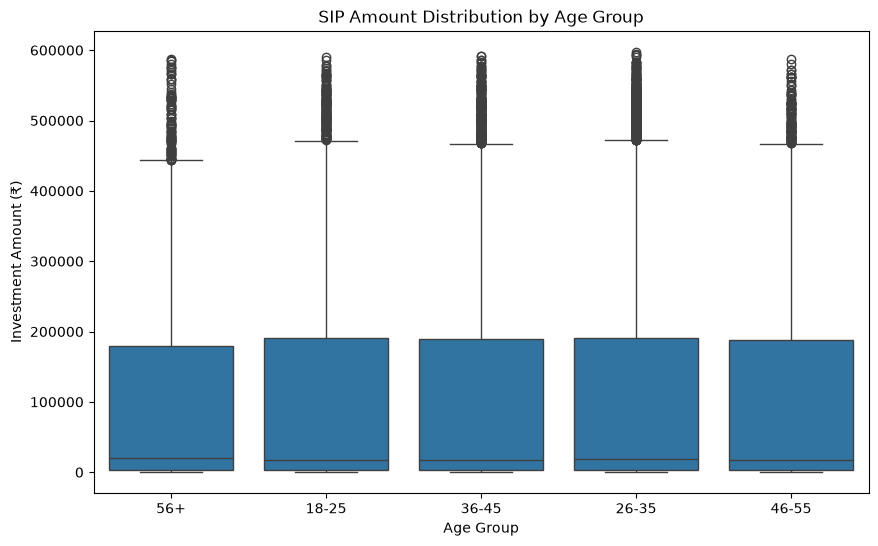

In [25]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")

plt.xlabel("Age Group")
plt.ylabel("Investment Amount (₹)")

plt.savefig("../reports/SIP_Boxplot_Age.png", dpi=300)

plt.show()

### Insight 6

Investment amounts vary across age groups. Some age groups show higher variability, indicating a wider range of investment behavior.

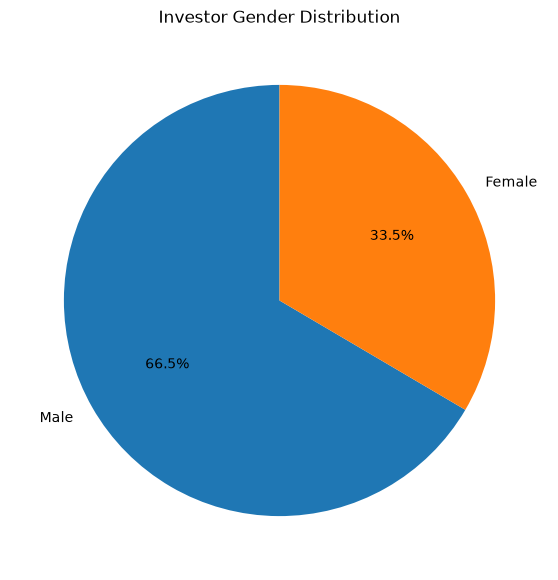

In [26]:
gender = transactions["gender"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender,
    labels=gender.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Gender Distribution")

plt.savefig("../reports/Gender_Pie.png", dpi=300)

plt.show()

### Insight 7

The dataset shows the distribution of investors by gender, helping understand participation across different investor groups.

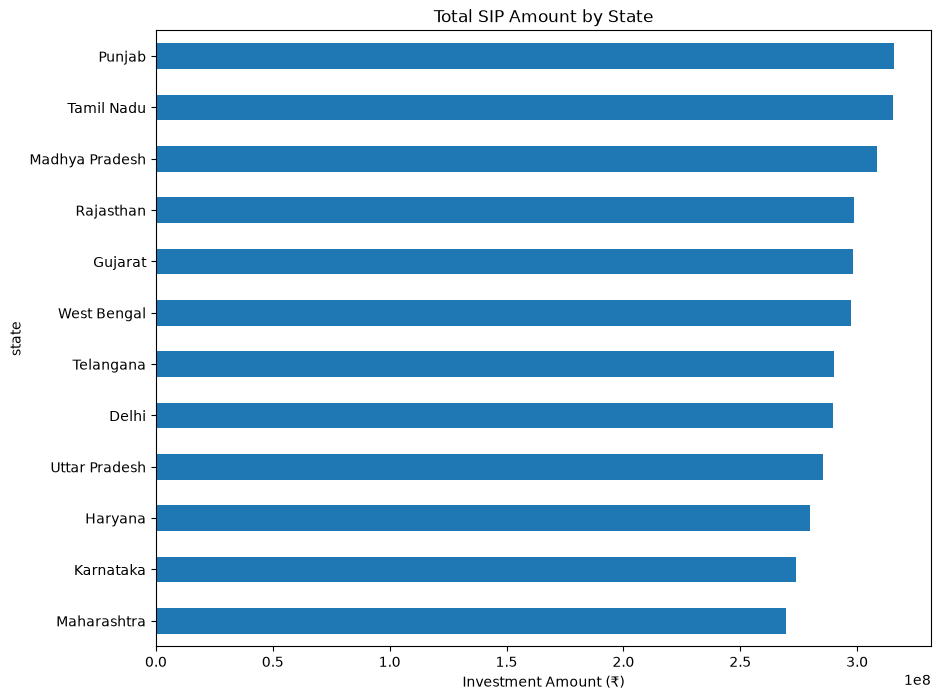

In [27]:
state_amount = transactions.groupby("state")["amount_inr"].sum().sort_values()

plt.figure(figsize=(10,8))

state_amount.plot(kind="barh")

plt.title("Total SIP Amount by State")

plt.xlabel("Investment Amount (₹)")

plt.savefig("../reports/State_SIP.png", dpi=300)

plt.show()

### Insight 8

Some states contribute significantly more to SIP investments than others, reflecting regional differences in mutual fund participation.

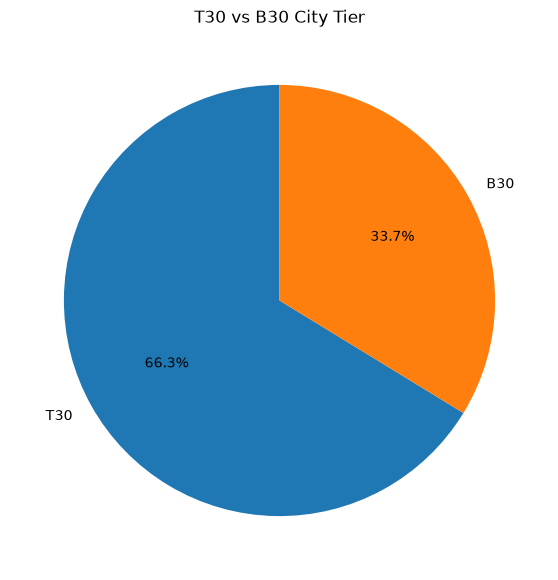

In [28]:
tier = transactions["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    tier,
    labels=tier.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 City Tier")

plt.savefig("../reports/City_Tier.png", dpi=300)

plt.show()

### Insight 9

Investors from both T30 and B30 cities contribute to mutual fund investments, showing the growing reach of SIPs beyond major metropolitan areas.

## Finding 1

Daily NAV values generally increased during 2023, indicating a strong bull market. Small corrections were visible during 2024.

## Finding 2

SBI Mutual Fund recorded the highest Assets Under Management among all fund houses during the analysis period.

In [29]:
## Finding 1

Daily NAV values generally increased during 2023, indicating a strong bull market. Small corrections were visible during 2024.

SyntaxError: invalid syntax (2771259592.py, line 3)

## Finding 3

Monthly SIP inflows increased steadily and reached an all-time high of ₹31,002 crore in December 2025.

## Finding 4

Large Cap and Flexi Cap categories attracted the highest net inflows across most months.

## Finding 5

The 26–35 age group represents the largest share of mutual fund investors.

## Finding 6

Both T30 and B30 cities contribute significantly to SIP investments, showing wider market participation.

## Finding 7

Industry folio count nearly doubled from 13.26 crore in January 2022 to 26.12 crore in December 2025.

## Finding 8

Several mutual funds exhibited strong positive correlation in their daily NAV returns.

## Finding 9

Banking and Information Technology sectors account for the largest portfolio allocations.

## Finding 10

Most mutual fund schemes maintained expense ratios within the expected industry range.